# 13 · Suspensions and emulsions

Cement paste, paints, mine tailings, chocolate, blood, mayonnaise: most engineering fluids are particles or
droplets in a liquid. Their viscosity rises dramatically as the particles crowd together, diverging at a
**maximum packing fraction**; at high concentrations they may develop a yield stress or even thicken under
shear.

**What you will learn**
- predict suspension viscosity from the volume fraction (Einstein, Krieger-Dougherty)
- fit the maximum packing fraction and appreciate the sensitivity near it
- recognise shear thickening and its process risks

**Before you start:** notebooks 03-04  ·  **Time:** about 45-60 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, suspensions as su
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

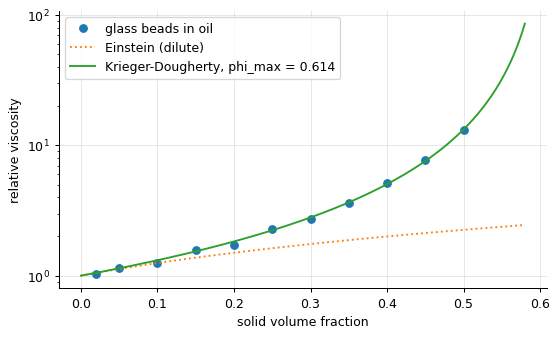

[eta] fixed at 2.5: phi_max = 0.614;  both free: phi_max = 0.609, [eta] = 2.47
true: phi_max = 0.61, [eta] = 2.5


In [2]:
gb = pd.read_csv(datasets.path("glass_beads_suspension.csv"), comment="#")
phi, eta_r = gb.volume_fraction.to_numpy(), gb.relative_viscosity.to_numpy()
fixed = su.fit_krieger_dougherty(phi, eta_r)                    # [eta] = 2.5 for spheres
free = su.fit_krieger_dougherty(phi, eta_r, fix_intrinsic=None)
pp = np.linspace(0, 0.58, 200)
plt.semilogy(phi, eta_r, "o", label="glass beads in oil")
plt.semilogy(pp, su.einstein(pp), ":", label="Einstein (dilute)")
plt.semilogy(pp, su.krieger_dougherty(pp, fixed["phi_max"]), label=f"Krieger-Dougherty, phi_max = {fixed['phi_max']:.3f}")
plt.xlabel("solid volume fraction"); plt.ylabel("relative viscosity"); plt.legend(); plt.show()
print(f"[eta] fixed at 2.5: phi_max = {fixed['phi_max']:.3f};  both free: phi_max = {free['phi_max']:.3f}, [eta] = {free['intrinsic']:.2f}")
print("true: phi_max = 0.61, [eta] = 2.5")

Einstein's result holds only in the dilute limit. Krieger-Dougherty captures the whole curve with one
parameter, the maximum packing fraction (about 0.58-0.64 for monodisperse spheres, depending on packing).

## Close to maximum packing, everything is sensitive

In [3]:
pm = fixed["phi_max"]
for p_ in (0.40, 0.50, 0.55, 0.58):
    print(f"phi = {p_:.2f}: eta_r = {su.krieger_dougherty(p_, pm):8.1f};  +0.01 in phi -> x{su.krieger_dougherty(p_ + 0.01, pm)/su.krieger_dougherty(p_, pm):.2f}")
for pm2 in (pm, pm + 0.05, pm + 0.10):
    print(f"phi_max = {pm2:.2f} (broader size distribution): eta_r at phi = 0.55 is {su.krieger_dougherty(0.55, pm2):6.1f}")

phi = 0.40: eta_r =      5.0;  +0.01 in phi -> x1.08
phi = 0.50: eta_r =     13.3;  +0.01 in phi -> x1.15
phi = 0.55: eta_r =     32.4;  +0.01 in phi -> x1.30
phi = 0.58: eta_r =     86.2;  +0.01 in phi -> x1.72
phi_max = 0.61 (broader size distribution): eta_r at phi = 0.55 is   32.4
phi_max = 0.66 (broader size distribution): eta_r at phi = 0.55 is   18.7
phi_max = 0.71 (broader size distribution): eta_r at phi = 0.55 is   13.8


Near maximum packing a one-percent change in solids content changes the viscosity by tens of percent. The
same sensitivity is an opportunity: mixing particle sizes lets small particles fill the gaps between large
ones, raising $\phi_{max}$ (the Farris effect). That is how concrete, chocolate and ceramic slurries reach high
solids contents at a pumpable viscosity.

## When suspensions thicken: cornstarch

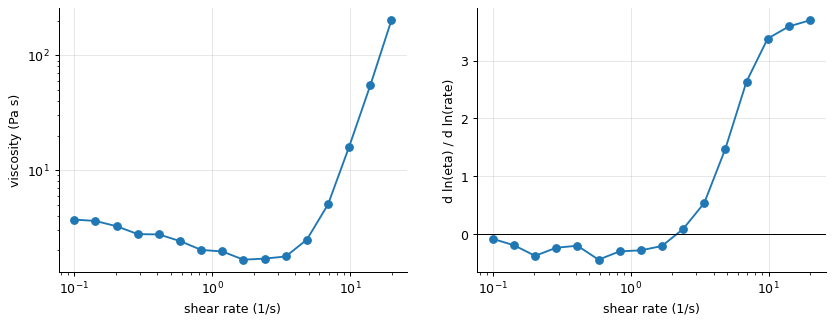

minimum viscosity 1.66 Pa s at 1.7 1/s; at the highest rate 201.5 Pa s


In [4]:
cs = pd.read_csv(datasets.path("cornstarch_flow_curve.csv"), comment="#")
rate, eta = cs.shear_rate_1_s.to_numpy(), cs.viscosity_Pa_s.to_numpy()
slope = np.gradient(np.log(eta), np.log(rate))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.loglog(rate, eta, "o-"); a1.set(xlabel="shear rate (1/s)", ylabel="viscosity (Pa s)")
a2.semilogx(rate, slope, "o-"); a2.axhline(0, color="k", lw=0.8)
a2.set(xlabel="shear rate (1/s)", ylabel="d ln(eta) / d ln(rate)"); plt.show()
print(f"minimum viscosity {eta.min():.2f} Pa s at {rate[np.argmin(eta)]:.1f} 1/s; at the highest rate {eta[-1]:.1f} Pa s")

Dense suspensions of non-Brownian particles first shear-thin, then thicken sharply as frictional contacts
form between particles. For process equipment this is dangerous: pumping or mixing such a slurry faster
can raise the resistance abruptly, even jam the flow. Know where thickening starts before choosing
pump or mixer speeds.

**Emulsions** behave similarly with droplets instead of particles - but droplets deform, so emulsions can
exceed the packing limit of spheres: mayonnaise (over 75 % oil) is a soft solid with a yield stress because
its droplets are squeezed against each other.

## Inside the algorithm: fitting the maximum packing fraction
With $[\eta]$ fixed, Krieger-Dougherty has one parameter; scan $\phi_{max}$ and minimise the squared log residuals:

In [5]:
grid = np.linspace(phi.max() + 0.005, 0.8, 4000)
sse = [np.sum((np.log(su.krieger_dougherty(phi, g)) - np.log(eta_r))**2) for g in grid]
print(f"by hand: phi_max = {grid[int(np.argmin(sse))]:.4f};  library: {fixed['phi_max']:.4f}")

by hand: phi_max = 0.6136;  library: 0.6136


## Exercises
1. What solids fraction gives a relative viscosity of 10 with the fitted $\phi_{max}$? And of 100?
2. At a fixed solids content of 0.55, by what factor does the viscosity fall if a broader size distribution raises $\phi_{max}$ from the fitted value to 0.70?
3. **Implement it yourself:** tabulate the Einstein, Batchelor and Krieger-Dougherty predictions at $\phi$ = 0.02, 0.05, 0.1 and 0.2 and compare them with the data. Where does each fail?